# Analysing Sequencing Data 

# Notebook Guide — What this pipeline does (and how)

This notebook runs an **end-to-end read → plasmid-feature alignment** workflow powered by `assembly_designer.plasmidio`. Paste this cell at the top of your notebook.

---

## Overview

**Goal:** map Sanger/NGS reads to **annotated plasmid features** (promoter, RBS, CDS, …), decide the **best hit per read**, and produce a tidy results table + optional visualizations.

**Main steps:**
1. **Prepare plasmids** → read GenBank files, filter/normalize features, and build a **concatenated feature reference** (per plasmid) + **k-mer index** for seeding.
2. **Load reads** → FASTA/FASTQ (file or folder), optional end trimming.
3. **Align batch** → fast **k-mer seeding** to shortlist candidates, then a **read-anchored semi-global alignment** for precise scoring, on forward & reverse strands.
4. **Pick best hit** per read (by configurable PID definition), convert to a **DataFrame**, and optionally **export** (XLSX/CSV) or **plot/view** alignments.

---

## Inputs & outputs

- **Inputs**
  - `plasmids_dir`: folder with `.gb/.gbk` (annotated features).
  - `reads_input`: FASTA/FASTQ file or folder of files.
  - Feature filters: `include_tokens`, `exclude_tokens`, `allowed_types`.
  - Alignment controls: `k`, `top_k`, `margin`, `step`, `try_both_strands`.
  - PID definition: `pid_mode = "read" | "feature" | "feature_len"`.

- **Outputs**
  - `df`: one **best-hit row per read** (percent identity, coordinates, features hit, etc.).
  - Optional: `alignment_results.xlsx` (and `snps.txt` if requested).
  - Optional viewers: static plots or interactive HTML for a single hit.

---

## What “prepare plasmids” does

`prepare_plasmids(...)`:
- Loads each GenBank, **filters** features by name/type (e.g. keep promoters/RBS, drop backbones).
- **Concatenates** kept features (in plasmid order) into a single synthetic reference string: `concat_ref`.
- Builds a **feature map**: precise intervals in `concat_ref` with original names/types (e.g., `misc_feature:J23107`, `RBS:B0034m`).
- Builds a **k-mer index** (default `k=11`) over `concat_ref` for fast read seeding.

> Why concatenate? We align against exactly the parts that matter (designed features) in a compact coordinate system, with backbones/oris filtered out if desired.

---

## Seeding: Top-K candidate selection

For each read:
- Subsample the read’s k-mers (every `step` bases) and count matches in each plasmid’s k-mer index.
- Keep only the **Top-K** plasmids (`top_k`) with the highest hit count → major speedup.
- `margin` widens the local window around the best seed hits when setting up the DP band.

---

## Alignment algorithm

Per read × candidate plasmid:
- Try **both strands** if `try_both_strands=True` (forward and reverse-complement).
- Run a **read-anchored semi-global alignment** using **Biopython**’s `pairwise2` (global with modified scoring):
  - Scoring defaults: `match=+1.0`, `mismatch=-1.0`, `gap_open=-1.5`, `gap_extend=-0.5`.
  - Uses `pairwise2.align.globalms` under the hood, constrained to the seeded window/band.
- Compute **SNPs** (base mismatches) and record **per-feature coverage & identity** within the aligned core.

**Percent identity (PID) modes:**
- `pid_mode="read"` → % identity relative to the **aligned read core length**.  
- `pid_mode="feature"` → % identity relative to the **overlap length** with the feature region(s).  
- `pid_mode="feature_len"` → % identity relative to the **full feature length** (in the hit interval).  
  - Use this to answer: “Is the feature fully present and perfect?”

**Best-hit selection:** pick the row with **highest PID**; on ties, use **higher raw score**.

---

## The results table (`df`)

Each row summarizes the best plasmid-feature hit for one read:

- `sequence_name` — read ID; `read_len` — read length after trimming.  
- `plasmid_file`, `plasmid_id`, `construct` — where the hit lives.  
- `strand` — `F` or `R` (reverse-complement).  
- `pid` — percent identity (per your `pid_mode`).  
- `core_len` — aligned core length (bases of the read that were aligned).  
- `score` — raw alignment score (match/mismatch/gap model).  
- `start_ref`, `end_ref` — coordinates on `concat_ref`.  
- `features_hit` — list like `misc_feature:J23107 (100%), RBS:B0034m (100%)`.  
- `snps` — number of single-base differences in the core.  
- `concat_pos` — formatted `start_ref–end_ref`.  
- (Optional) `pid_mode` — for clarity when comparing runs.

---

## Visual inspection (optional)

- **Static plots:**  
  `plot_alignment(row, plasmids, reads, wrap=90, full_track=True)`  
  `plot_alignment_by_ref("73802037", df, plasmids, reads, wrap=90)`

- **Interactive HTML (Jupyter):**  
  `view_alignment_html(row, plasmids, reads, wrap=90, theme="dark", font_px=13)`  
  `view_alignment_html_by_ref("73802037", df, plasmids, reads)`

These visualize the read vs. the concatenated feature track with per-feature highlights.

---

## Interpreting common cases

- `features_hit` shows the **exact features** covered inside `start_ref–end_ref`, with a **local % identity** for each.
- In `pid_mode="feature_len"`, a feature reported as **(100%)** means the **entire feature** is covered by the read core with perfect identity.
- `snps=0` often corresponds to `pid=100.0` for the relevant denominator, but gaps and denominator choice matter—check `pid_mode`.

---

## Parameter tips

- **k (k-mer size):** 9–13 is typical. Smaller → more sensitive, more false seeds; larger → faster but can miss noisy reads.  
- **top_k:** 3–8 keeps it fast. If you have many similar constructs, increase slightly.  
- **margin:** 100–300 to allow room around seeds for DP.  
- **step:** 1–3 is a good range; larger skips more k-mers → faster but riskier.  
- **try_both_strands:** keep `True` unless you know orientation.  
- **pid_mode:**  
  - “Is the **feature complete**?” → `feature_len`  
  - “How well does the **read** align?” → `read`  
  - “Normalize by **overlap only**” → `feature`

---

## SNP report (optional)

Pass `snp_report_path="snps.txt"` to `align_batch(...)` to write a human-readable list of SNPs per read×plasmid hit (coordinates, ref→read changes).

---

## Troubleshooting

- **No plasmids prepared:** check `plasmids_dir`, file extensions, or relax filters (`include_tokens`, `exclude_tokens`, `allowed_types`).  
- **No reads loaded:** verify path/format; reduce `trim_left/right`.  
- **Missing RBS/promoter in output:** ensure the feature is **annotated** in GenBank (correct `type` and/or name token), and that your filters don’t exclude it.  
- **Many ties:** consider stricter `pid_mode`, adjust scoring, or verify annotations (overlapping features can share the same interval).

---

## Key functions you’ll see

- `prepare_plasmids(...)` → feature concat + k-mer index per plasmid.  
- `load_reads(...)` → FASTA/FASTQ → `ReadItem[]`.  
- `align_batch(...)` → seeding + read-anchored alignment + best-hit selection.  
- `results_to_dataframe(rows)` → tidy table of best hits.  
- `export_results(df, ...)`, `export_feature_inventory(...)` → XLSX/CSV exports.  
- `plot_alignment(...)`, `view_alignment_html(...)` → QA/visualization.

> All steps are **deterministic** for the same inputs and parameters, making it easy to rerun and compare different `pid_mode` or filter settings.


## What is a *k*-mer & what is a *k*-mer index?

**k-mer** = short DNA word of fixed length *k* (e.g., for *k*=11, an 11-base sequence such as `ACGTT...`).  
**k-mer index** = a reference work (hash map) that stores **where** each such word occurs in the reference.

Mini example:
```text
index[“ACGTTCGATGA”] → [123, 982]
index[“CGATGAATTCT”] → [456]

In [1]:
# Core
from pathlib import Path
from typing import Union
import re
import pandas as pd
import matplotlib.pyplot as plt

# Package
import assembly_designer as ad
import assembly_designer.plasmidio as p

# Plasmidio API (one place)
from assembly_designer.plasmidio import (
    # I/O & prep
    prepare_plasmids, load_reads, load_dna_file,
    # Alignment
    align_batch, align_batch_parallel, dealign_reads_easy, read_anchored_align,
    # Results / export
    results_to_dataframe, export_results, export_feature_inventory,
    # Picking / utils
    revcomp, normalize_ref_id, pick_row_by_ref,
    # Visualization
    plot_alignment, plot_alignment_by_ref,
    view_alignment, view_alignment_by_ref,
    view_alignment_html, view_alignment_html_by_ref,
    summarize_matches,
    find_unbuilt_plasmids,
)

# Versions / locations
print("assembly-designer version:", getattr(ad, "__version__", "unknown"))
print("plasmidio module file :", p.__file__)

# (Optional) nicer Pandas rendering
pd.set_option("display.max_colwidth", 140)



assembly-designer version: 0.0.1.dev22+gb112bada6.d20251005
plasmidio module file : C:\Repo\assembly_designer_test\assembly_designer\plasmidio\__init__.py


## Helpers

In [2]:
# helper:

def find_by_ref(df: pd.DataFrame, ref: Union[str, int], *, min_pid: float = 0.0) -> pd.DataFrame:
    """
    Return rows whose `sequence_name`'s numeric id equals `ref`, best-first.
    """
    key = df["sequence_name"].astype(str).map(normalize_ref_id)
    out = df[key.eq(str(ref))]
    if min_pid > 0:
        out = out[out["pid"] >= float(min_pid)]
    return out.sort_values(["pid", "score"], ascending=[False, False])


def norm_ref(s: str) -> str:
    m = re.search(r"[0-9]+", str(s))
    return m.group(0) if m else ""



## Parameters

- **`step` ↓** *(e.g., 4 → 1)*
Closer sliding of the k-mer window ⇒ more seeds ⇒ **≈2–4× slower**.

- **`margin` ↑** *(e.g., 250–300)*  
  larger reference window per candidate ⇒ longer alignments ⇒ **linearly more expensive**.

- **`top_k` ↑ / `within` more generous** *(e.g., 0.90–0.92)*  
  more candidates make it into the fine selection ⇒ **linearly** more alignments.

- **`k` ↓** *(e.g., 10 → 9 or 8)*  
  more sensitive to small differences (RBS/5′UTR), but more random hits ⇒ **slower**.  
  ⚠️ **Set the same value in** `prepare_plasmids(k=…)` **as well!**

- **`try_both_strands = True`**  
  roughly doubles the alignments if you do not select the strand beforehand.


In [3]:

# ── Inputs ─────────────────────────────────────────────────────────────────────
# File with sequencing reads. Can be:
#   • a single FASTA/FASTQ file, OR
#   • a folder that contains multiple FASTA/FASTQ files.
reads_input = Path("Sequencing_Data_ecPanD.fasta") 
 
# Folder that contains your reference plasmids in GenBank format (.gb / .gbk).
# These are the *assembled* constructs you want to check the reads against.
plasmids_dir = Path("../../02 insilico Plasmid Construction/01 GoldenGateCloning/reports/Assembly")


# ── Seeding / alignment controls ───────────────────────────────────────────────
# K-mer length used for fast seeding (11 is a good default for Sanger-length reads).
k = 16

# For each read, we only align against the Top-K candidate plasmids (ranked by seed hits).
# This keeps the run fast while still being robust.
top_k = 6

# Extra bases added to the seeded window on the reference (left/right).
# Larger margin = more robust to noisy seeds, but slower.
margin =300

# Also try the reverse complement of the read and keep the better strand.
try_both_strands = True

# Seeding stride (bp): slide k-mer window every 'step' bases.
# Larger = faster but less sensitive; smaller = slower but more sensitive.
step = 4

# ── Optional read trimming ────────────────────────────────────────────────────
# If your reads have low-quality ends, trim a fixed number of bases
# at the 5' (left) and 3' (right) ends before alignment.
trim_left  = 0
trim_right = 0


# ── Feature filter (what parts of the plasmid to keep in the concat-band) ─────
# Only features whose *display name* contains ANY of these tokens are kept.
# (Case-insensitive substring match.) Remove tokens you don't need.
include_tokens = ["J231", "R0010", "BCD", "ecPanD", "B0032m", "B0033m", "B0034m", "B0015"]

# Features whose *display name* contains ANY of these tokens are excluded.
# Typical choices to drop backbone/ori/utility annotations.
# WARNING: 'CDS' here excludes coding sequences; keep it only if you *do not*
# want the gene region in the alignment reference.
exclude_tokens = None #("dvl1", "backbone", "vector", "ori")

# Allowed GenBank feature types to consider in general.
# (Types are compared as written in the GenBank; usual ones are shown below.)
allowed_types = ("promoter", "RBS", "CDS", "terminator", "misc_feature","5'UTR","3'UTR")


# ── Output files ──────────────────────────────────────────────────────────────
# Where to save the tabular summary (CSV/XLSX is chosen later by export function).
out_xlsx = Path("alignment_results.xlsx")

# If you also want a SNP list (per read, per plasmid), set a path.
# Example: Path("snps.txt"). Keep None to skip writing a SNP report.
snp_report = Path("snps.txt")


# ── (Advanced / optional) PID definition ──────────────────────────────────────
# In case you want to switch PID calculation modes when calling `align_batch`:
#   "read"        → matches / read bases in the core (stable across read lengths)
#   "feature"     → matches / aligned columns that fall INSIDE features only
#   "feature_len" → matches / reference feature length inside the aligned span
# pid_mode = "read"



## Alignment

### PID modes (what’s the denominator?)

#### `read`
- **Definition:** `PID = matches / (alignment columns where both sides are bases)`
- **Scope:** Entire read (feature-agnostic).
- **Use when:** You want a robust, length-stable score across reads.

#### `feature`
- **Definition:** `PID = matches / (alignment columns whose reference position lies *inside features*)`
- **Scope:** Only the **aligned** portion that overlaps features.
- **Effect:** Does **not** penalize unaligned/trimmed parts of features.
- **Use when:** You want to evaluate identity *within* features without punishing partial coverage.

#### `feature_len`
- **Definition:** `PID = matches / (total feature length in the reference window)`
- **Scope:** The full **feature span** in the window, including parts that weren’t aligned.
- **Effect:** Penalizes **missing coverage** (clipping, gaps) within features.
- **Use when:** You want a stricter metric that distinguishes close variants (e.g., RBS/5′UTR) by rewarding full coverage.

---

#### Mini example
Feature length in window = **100 bp**  
Alignment overlaps the feature for **80 columns**, with **72 matches**.

- `feature` → `72 / 80 = 90%`  
- `feature_len` → `72 / 100 = 72%` (stricter due to unaligned 20 bp counted in the denominator)

---

#### Practical notes
- Make sure your `allowed_types` include all relevant annotations (e.g., `RBS` **and** `5'UTR`) so feature-based PID can see them.
- Very **small windows** (`margin`/`max_window_bp`) can unfairly lower `feature_len` (because unaligned feature bases still count in the denominator).
- For most workflows: start with `read`, then switch to `feature` or `feature_len` when you specifically need per-feature discrimination.


In [4]:
pid_mode = "feature_len"  

In [ ]:
# # # Export results (XLSX + optional SNP report)

# 1) Construct references (Note: k must match prepare_plasmids!)
plasmids = prepare_plasmids(
    str(plasmids_dir),
    k=k,
    include_tokens=include_tokens,
    exclude_tokens=exclude_tokens,
    allowed_types=allowed_types,
)
print(f"Prepared {len(plasmids)} plasmid references.")

# 2) Load reads (set optional trimming here)
reads = load_reads(str(reads_input), trim_left=trim_left, trim_right=trim_right)
print(f"Loaded {len(reads)} reads.")

Prepared 42 plasmid references.
Loaded 44 reads.


In [6]:
# # 3) Parallel alignment (thread)
# rows = align_batch_parallel(
#     plasmids, reads,
#     backend="threads",
#     workers=8,
#     k=k, step=step, margin=margin, top_k=top_k, within=0.90,
#     try_both_strands=True, pid_mode=pid_mode,
# )
# df = results_to_dataframe(rows).sort_values(["sequence_name","pid","score"], ascending=[True, False, False])
# df.head(10)


In [7]:
# # Alignment (single-threaded, simpler)
# rows = align_batch(
#     plasmids, reads,
#     k=k, margin=120, step=4, top_k=6,
#     try_both_strands=True,
#     pid_mode="feature",          # "read" | "feature" | "feature_len"
#     snp_report_path="snps.txt",      # optional: SNP-Report 
#     show_progress=True,              
#     progress_desc="Aligning reads",
# )
# df = results_to_dataframe(rows)
# df.head(10)


In [8]:
# Using the easy wrapper (multi-threaded, with retries and fallback)

rows, df = p.dealign_reads_easy(
    reads_input=reads_input,
    plasmids_dir=plasmids_dir,
    include_tokens=include_tokens,
    exclude_tokens=("dvl1","backbone","vector","ori"),
    allowed_types=("promoter","RBS","CDS","terminator","misc_feature","5'UTR","3'UTR"),
    # — Seeding/Alignment (entspannt) —
    k=k, step=2, margin=150, within=0.97, top_k=10, pid_mode=pid_mode,
    try_both_strands=True, min_jaccard=0.0,
    backend="threads", workers=8,
    read_aligner="pairwise2",               
    fallback_read_aligner="pairwise2",                     
)


New aligner: True
Using: pairwise2
Prepared 42 plasmid references.
Loaded 44 reads.


c:\Users\stoltmann\AppData\Local\mambaforge\envs\adesigner\Lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


[align] finished=0 pending=44
[align] finished=0 pending=44
[align] finished=0 pending=44
[align] finished=0 pending=44
[align] finished=1 pending=42
[align] finished=6 pending=38
[align] finished=8 pending=36
[align] finished=8 pending=36
[align] read 'EF73802062_EF73802062' timeout → retry 1/2
[align] finished=11 pending=33
[align] finished=11 pending=31
[align] finished=14 pending=30
[align] read 'EF73802074_EF73802074' timeout → retry 1/2
[align] finished=15 pending=29
[align] finished=16 pending=27
[align] finished=20 pending=24
[align] finished=21 pending=23
[align] finished=21 pending=23
[align] finished=23 pending=21
[align] read 'EF73802097_EF73802097' timeout → retry 1/2
[align] finished=25 pending=18
[align] finished=27 pending=17
[align] finished=29 pending=15
[align] finished=29 pending=14
[align] finished=32 pending=12
[align] read 'EF73802062_EF73802062' timeout → retry 2/2
[align] read 'EF73802074_EF73802074' timeout → retry 2/2
[align] finished=35 pending=6
[align] fin

In [9]:
len(df)

41

### Visulize output

In [ ]:
# ── Sum results ────────────────────────────────────────────────────────────

summary = summarize_matches(rows, min_pid=90.0)
missing = find_unbuilt_plasmids(plasmids, rows, min_pid=90.0)

display(summary)
print("---------------------------- missing --------------------------")
display(missing)
print(f"Planned: {len(plasmids)} | with Match ≥90%: {len(summary)} | without Match: {len(missing)}")


,plasmid_id,construct,plasmid_file,n_reads,best_pid,mean_pid
27,R0010_AB_B0032m_BC_D,B0032m_ecPanD_B0015,R0010_AB_B0032m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,2,100.000000,100.000000
28,R0010_AB_B0033m_BC_D,B0033m_ecPanD_B0015,R0010_AB_B0033m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,2,100.000000,100.000000
29,R0010_AB_B0034m_BC_D,B0034m_ecPanD_B0015,R0010_AB_B0034m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,1,100.000000,100.000000
30,R0010_AB_BCD12_BC_DV,BCD12_ecPanD_B0015,R0010_AB_BCD12_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,1,99.874055,99.874055
31,R0010_AB_BCD8_BC_DVA,BCD8_ecPanD_B0015,R0010_AB_BCD8_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,2,100.000000,99.937028
0,J23100_AB_B0032m_BC_,J23100_B0032m_ecPanD_B0015,J23100_AB_B0032m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,1,100.000000,100.000000
1,J23100_AB_B0033m_BC_,J23100_B0033m_ecPanD_B0015,J23100_AB_B0033m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,2,100.000000,100.000000
2,J23100_AB_B0034m_BC_,J23100_B0034m_ecPanD_B0015,J23100_AB_B0034m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,1,100.000000,100.000000
3,J23100_AB_BCD12_BC_D,J23100_BCD12_ecPanD_B0015,J23100_AB_BCD12_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,1,100.000000,100.000000
4,J23102_AB_B0032m_BC_,J23102_B0032m_ecPanD_B0015,J23102_AB_B0032m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,1,100.000000,100.000000


---------------------------- missing --------------------------


,plasmid_id,construct,plasmid_file
9,R0010_AB_BCD2_BC_DVA,BCD2_ecPanD_B0015,R0010_AB_BCD2_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb
0,J23100_AB_BCD2_BC_DV,J23100_BCD2_ecPanD_B0015,J23100_AB_BCD2_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb
1,J23100_AB_BCD8_BC_DV,J23100_BCD8_ecPanD_B0015,J23100_AB_BCD8_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb
2,J23102_AB_BCD2_BC_DV,J23102_BCD2_ecPanD_B0015,J23102_AB_BCD2_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb
3,J23103_AB_B0032m_BC_,J23103_B0032m_ecPanD_B0015,J23103_AB_B0032m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb
4,J23103_AB_BCD2_BC_DV,J23103_BCD2_ecPanD_B0015,J23103_AB_BCD2_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb
5,J23106_AB_BCD2_BC_DV,J23106_BCD2_ecPanD_B0015,J23106_AB_BCD2_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb
6,J23107_AB_BCD2_BC_DV,J23107_BCD2_ecPanD_B0015,J23107_AB_BCD2_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb
7,J23116_AB_B0032m_BC_,J23116_B0032m_ecPanD_B0015,J23116_AB_B0032m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb
8,J23116_AB_BCD2_BC_DV,J23116_BCD2_ecPanD_B0015,J23116_AB_BCD2_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb


Geplant: 42 | mit Match ≥90%: 32 | ohne Match: 10


In [11]:
# Unmatched Reads 
matched = set(df["sequence_name"].unique())
unmatched = [r.name for r in reads if r.name not in matched]
len(unmatched), unmatched[:5]

(3,
 ['EF73802062_EF73802062', 'EF73802074_EF73802074', 'EF73802097_EF73802097'])

In [12]:
# --- export results to XLSX/CSV (optional) ---

if out_xlsx:
    export_results(rows, str(out_xlsx), fmt="xlsx")
    print("wrote:", out_xlsx.resolve())

wrote: C:\Repo\assembly_designer_test\examples\03 Sequencing\01 From single fasta\alignment_results.xlsx


In [13]:
# --- search by reference number ---

# example
ref = "73802034"
df_ref = find_by_ref(df, ref)
print(f"matches for #{ref}: {len(df_ref)}")
df_ref.head(20)

matches for #73802034: 1


,sequence_name,read_len,plasmid_file,plasmid_id,construct,strand,pid,core_len,score,start_ref,end_ref,snps,features_hit,concat_pos,min_feature_pid,rbs_pid,n_features_below_95,suspicious,pid_mode
1,EF73802034_EF73802034,1186,J23100_AB_B0033m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,J23100_AB_B0033m_BC_,J23100_B0033m_ecPanD_B0015,F,100.0,577,556.0,0,565,0,"promoter:J23100 (100%), 5'UTR:B0033m (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–565,100.0,NaN,0,False,feature_len


In [14]:
# Your list of refs (as strings)
refs = ["73802034", "73802037", "12345"]

# Add a ref_key column (first continuous digit block from sequence_name)
tmp = df.assign(ref_key=df["sequence_name"].astype(str).map(norm_ref))

# Keep only requested refs
df_refs = tmp[tmp["ref_key"].isin(refs)].sort_values(["pid", "score"], ascending=[False, False])

# One best row per ref_key (highest PID, then highest score)
best_per_ref = df_refs.drop_duplicates("ref_key", keep="first")

# Which refs did not show up at all?
requested = set(refs)
found = set(best_per_ref["ref_key"].astype(str))
missing = sorted(requested - found)

print(f"rows kept: {len(df_refs)} | unique refs found: {best_per_ref['ref_key'].nunique()}")
print("missing refs:", missing)

best_per_ref[["ref_key","sequence_name","pid","core_len","plasmid_file","construct"]].head(20)


rows kept: 2 | unique refs found: 2
missing refs: ['12345']


,ref_key,sequence_name,pid,core_len,plasmid_file,construct
7,73802037,EF73802037_EF73802037,100.0,578,J23107_AB_B0034m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,J23107_B0034m_ecPanD_B0015
1,73802034,EF73802034_EF73802034,100.0,577,J23100_AB_B0033m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,J23100_B0033m_ecPanD_B0015


In [15]:
# ---- fuzzy search in sequence_name (substring, case-insensitive) ----

needle = "EF7380"   # any substring
df_fuzzy = df[df["sequence_name"].astype(str).str.contains(needle, case=False, na=False)] \
            .sort_values(["pid","score"], ascending=[False, False])
df_fuzzy.head(20)


,sequence_name,read_len,plasmid_file,plasmid_id,construct,strand,pid,core_len,score,start_ref,end_ref,snps,features_hit,concat_pos,min_feature_pid,rbs_pid,n_features_below_95,suspicious,pid_mode
29,EF73802095_EF73802095,1228,R0010_AB_BCD8_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,R0010_AB_BCD8_BC_DVA,BCD8_ecPanD_B0015,F,100.0,806,785.0,0,794,0,"promoter:R0010 (100%), 5'UTR:BCD8 (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–794,100.0,NaN,0,False,feature_len
4,EF73802038_EF73802038,1222,R0010_AB_B0032m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,R0010_AB_B0032m_BC_D,B0032m_ecPanD_B0015,F,100.0,744,723.0,0,732,0,"promoter:R0010 (100%), 5'UTR:B0032m (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–732,100.0,NaN,0,False,feature_len
9,EF73802050_EF73802050,1177,R0010_AB_B0032m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,R0010_AB_B0032m_BC_D,B0032m_ecPanD_B0015,F,100.0,744,723.0,0,732,0,"promoter:R0010 (100%), 5'UTR:B0032m (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–732,100.0,NaN,0,False,feature_len
19,EF73802061_EF73802061,1184,R0010_AB_B0034m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,R0010_AB_B0034m_BC_D,B0034m_ecPanD_B0015,F,100.0,743,722.0,0,731,0,"promoter:R0010 (100%), RBS:B0034m (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–731,100.0,NaN,0,False,feature_len
20,EF73802072_EF73802072,1240,R0010_AB_B0033m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,R0010_AB_B0033m_BC_D,B0033m_ecPanD_B0015,F,100.0,742,721.0,0,730,0,"promoter:R0010 (100%), 5'UTR:B0033m (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–730,100.0,NaN,0,False,feature_len
24,EF73802094_EF73802094,1230,R0010_AB_B0033m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,R0010_AB_B0033m_BC_D,B0033m_ecPanD_B0015,F,100.0,742,721.0,0,730,0,"promoter:R0010 (100%), 5'UTR:B0033m (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–730,100.0,NaN,0,False,feature_len
0,EF73802033_EF73802033,1175,J23102_AB_BCD12_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,J23102_AB_BCD12_BC_D,J23102_BCD12_ecPanD_B0015,F,100.0,641,620.0,0,629,0,"promoter:J23102 (100%), 5'UTR:BCD12 (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–629,100.0,NaN,0,False,feature_len
2,EF73802035_EF73802035,1171,J23103_AB_BCD8_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,J23103_AB_BCD8_BC_DV,J23103_BCD8_ecPanD_B0015,F,100.0,641,620.0,0,629,0,"promoter:J23103 (100%), 5'UTR:BCD8 (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–629,100.0,NaN,0,False,feature_len
5,EF73802045_EF73802045,1235,J23100_AB_BCD12_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,J23100_AB_BCD12_BC_D,J23100_BCD12_ecPanD_B0015,F,100.0,641,620.0,0,629,0,"promoter:J23100 (100%), 5'UTR:BCD12 (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–629,100.0,NaN,0,False,feature_len
11,EF73802047_EF73802047,1175,J23106_AB_BCD8_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,J23106_AB_BCD8_BC_DV,J23106_BCD8_ecPanD_B0015,F,100.0,641,620.0,0,629,0,"promoter:J23106 (100%), 5'UTR:BCD8 (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–629,100.0,NaN,0,False,feature_len


## 1. Simple Viz via Biopython

In [16]:
# --- use it ---
ref = "73802106"                 # your run/read number
row = df[df["sequence_name"].astype(str).map(norm_ref).eq(ref)].iloc[0]
view_alignment(row, plasmids, reads)

J23102_AB_BCD8_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb [0–629]  vs  EF73802106_EF73802106 (strand F; span=window)
PID=100.00%  core=641  score=620.0  SNPs=0
----------------------------------------------------------------------------------------------------
                                                                                                    
TAAGACTTACCTATAAAATAGGCGTATCACGAGGCAGAATTTCAGATAAAAAAAATCCTTAGCTTTCGCTAAGGATGATTTCTGGAATTCGCGGCCGCTT

-------------------------TTGACAGCTAGCTCAGTCCTAGGTACTGTGCTAGC----GGGCCCAAGTTCACTTAAAAAGGAGATCAACAATGA
                         |||||||||||||||||||||||||||||||||||    ||||||||||||||||||||||||||||||||||||
CTAGAGACTAGTGGAAGACATGGAGTTGACAGCTAGCTCAGTCCTAGGTACTGTGCTAGCTACTGGGCCCAAGTTCACTTAAAAAGGAGATCAACAATGA

AAGCAATTTTCGTACTGAAACATCTTAATCATGCATCGGACCGTTTCT----ATGATCAGAACCATGTTGCAAGGTAAATTGCACAGAGTTAAGGTTACT
||||||||||||||||||||||||||||||||||||||||||||||||    ||||||||||||||||||||||||||||||||||||||||||||||||
AAGCAATTTTCGTACTGAAACATCTTAATCATGCATCGGA

In [ ]:
# Variante B (minimaler Fallback ohne Helper)
ref = "73802034"
row = (
    df[df["sequence_name"].astype(str)
         .str.extract(r"([0-9]+)", expand=False)
         .eq(ref)]
    .sort_values(["pid", "score"], ascending=[False, False])
    .iloc[0]
)
view_alignment(row, plasmids, reads)     # Text-Viewer
# Optionally attractive in HTML:
# view_alignment_html(row, plasmids, reads, wrap=90, theme="dark", font_px=13)

J23100_AB_B0033m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb [0–565]  vs  EF73802034_EF73802034 (strand F; span=window)
PID=100.00%  core=577  score=556.0  SNPs=0
----------------------------------------------------------------------------------------------------
                                                                                                    
CTTAAGATTAACCTATAAAATAGGCGTATCACGAGGCAGAATTTCAGATAAAAAAAATCCTTAGCTTTCGCTAAGGATGATTTCTGGAATTCGCGGCCGC

---------------------------TTGACGGCTAGCTCAGTCCTAGGTACAGTGCTAGC----AGAGTCACACAGGACTACTA----ATGATCAGAA
                           |||||||||||||||||||||||||||||||||||    ||||||||||||||||||||    ||||||||||
TTCTAGAGACTAGTGGAAGACATGGAGTTGACGGCTAGCTCAGTCCTAGGTACAGTGCTAGCTACTAGAGTCACACAGGACTACTAAATGATGATCAGAA

CCATGTTGCAAGGTAAATTGCACAGAGTTAAGGTTACTCATGCTGACTTGCATTACGAAGGTTCTTGTGCTATTGATCAAGATTTCTTGGATGCTGCCGG
||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
CCATGTTGCAAGGTAAATTGCACAGAGTTAAGGTTACT

## 2. Extensive Viz

In [18]:
plasmids = prepare_plasmids(plasmids_dir, use_full_sequence=True)

sequence_name                                EF73802034_EF73802034
pid                                                          100.0
core_len                                                       577
plasmid_file     J23100_AB_B0033m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb
construct                               J23100_B0033m_ecPanD_B0015
concat_pos                                                   0–565
Name: 1, dtype: object

Showing ref #73802034 — rank 1, PID=100.00%


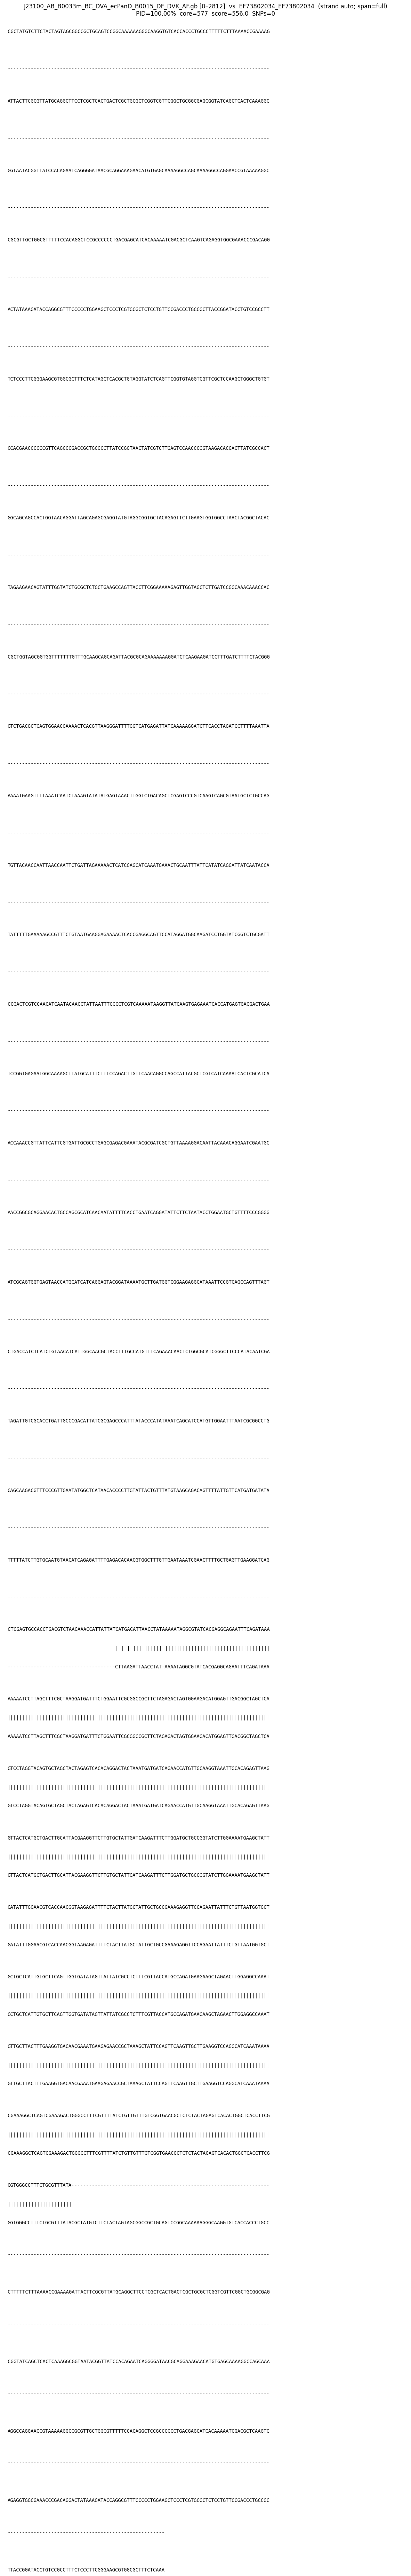

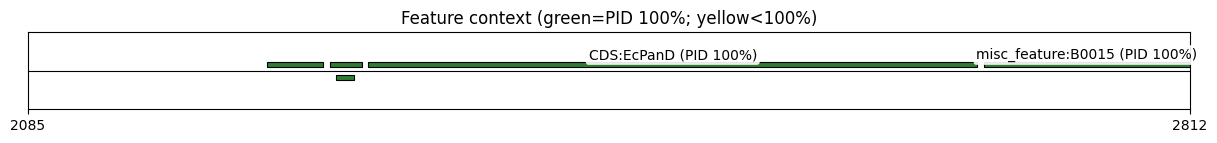

In [19]:
# --- Find all rows whose sequence_name contains the numeric ref token ----------
ref = "73802034"
hits = pick_row_by_ref(df, ref)   # your helper that returns a filtered DataFrame
display(hits[["sequence_name","pid","core_len","plasmid_file","construct","concat_pos"]]
        .head(20))

# --- Plot the best match (rank 1) with alignment + separate feature track -----
# Old -> New mapping:
# - feature_mode="window"     -> span="window" for alignment; feature_span="window" for the track
# - height_per_block          -> mid_per_block (controls vertical size per wrapped trio)
# - min_mid_height            -> not needed; use a larger mid_per_block instead
# - hit_thresh                -> pass into feature_track_kwargs
# - fig_width, wrap           -> unchanged

_ = plot_alignment_by_ref(
    ref,
    df,
    plasmids,
    reads,
    wrap=90,
    fig_width=15.0,
    span="full",                 # alignment over the reported window (use "full" for whole concat)
    feature_span="full",         # feature track also clipped to the window
    mid_per_block=0.55,            # was: height_per_block
    feature_track_kwargs=dict(     # styling for the bottom feature figure
        height=1.0,                # total height of the feature figure (in inches)
        rect_height=0.18,          # thickness of feature bars
        lane_gap=0.10,             # vertical gap between staircase lanes
        label_thresh=0.05,         # only label boxes wider than this fraction
        label_bbox=True,           # draw white label pill for readability
        label_bbox_alpha=0.9,
        zoom_to_features=True,     # auto-zoom the feature panel to the covered region
        pad_bp=150,                # padding (bp) left/right when zooming
    ),
)


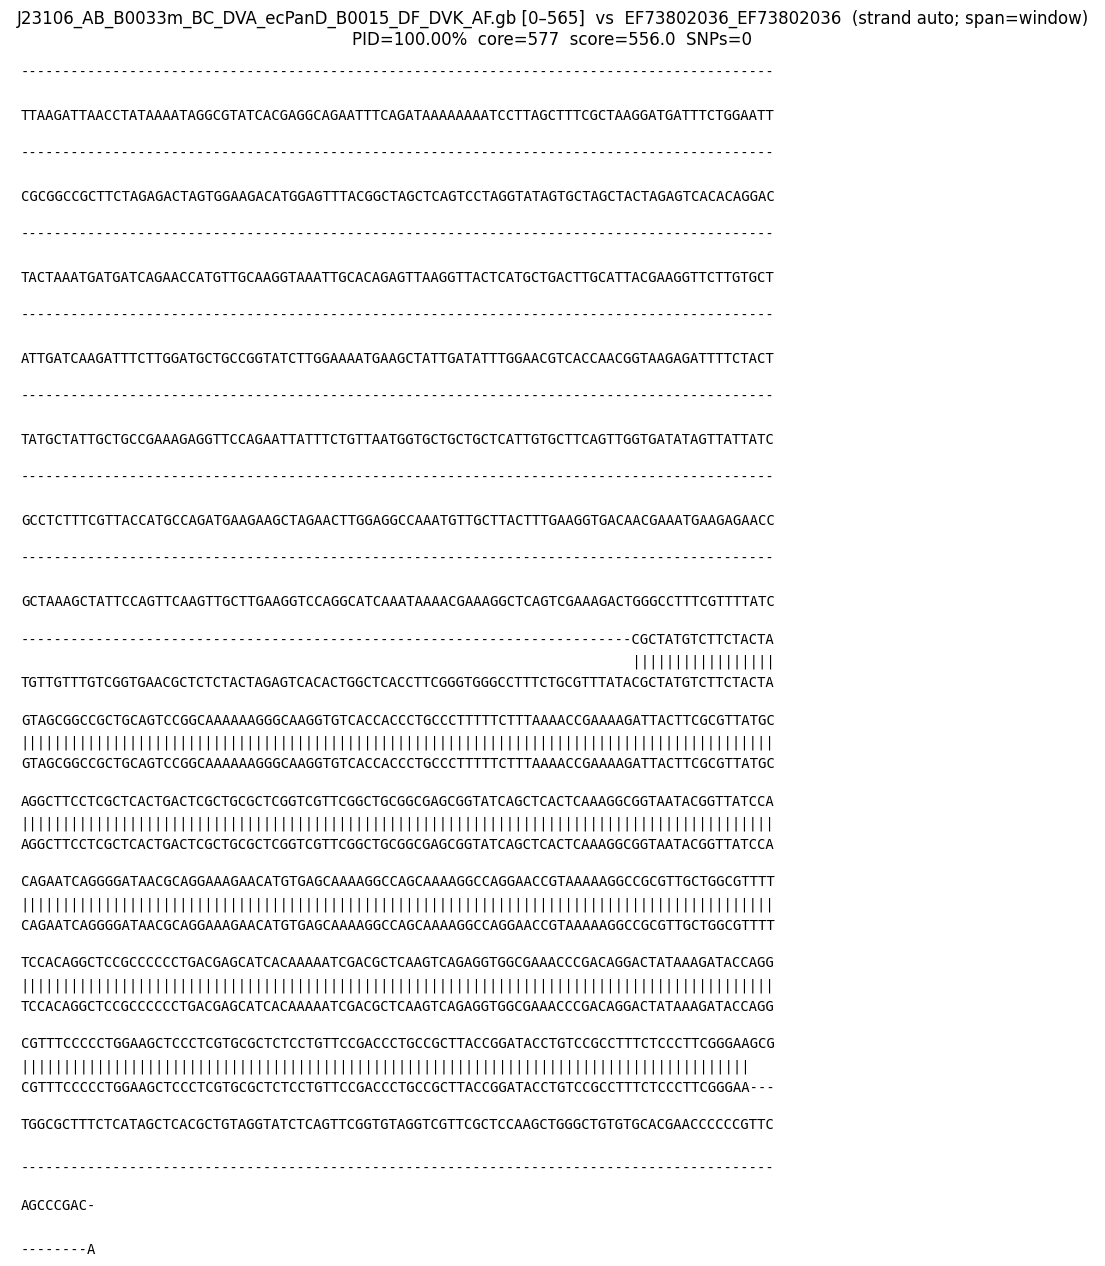

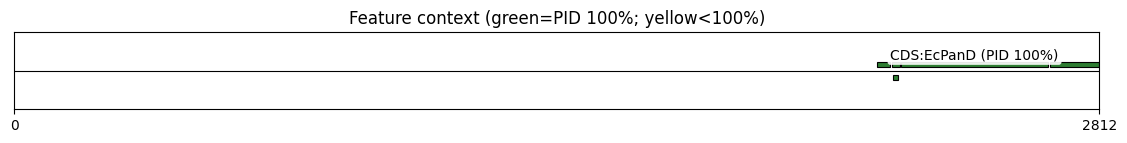

In [20]:
# You already picked a specific row:
row = df.iloc[3]

# Render BOTH figures:
#   fig_align = ASCII alignment
#   fig_feat  = separate feature-track figure
fig_align, fig_feat = plot_alignment(
    row,
    plasmids,
    reads,
    # Old feature_mode="window"  →  span="window" (for the alignment)
    span="window",
    # Old height_per_block/min_mid_height → mid_per_block controls vertical size per wrapped trio
    mid_per_block=0.55,
    # Keep your canvas width
    fig_width=14.0,
    # (optional) columns per wrapped line; add if you want bigger glyphs
    # wrap=90,
    feature_span="full",         # feature track also clipped to the window

    # Feature panel options go under feature_track_kwargs
    feature_track_kwargs=dict(
        # Make the feature panel reasonably tall & readable
        height=1.0,        # inches, overall figure height for the feature track
        rect_height=0.18,  # thickness of feature bars
        lane_gap=0.10,     # gap between “staircase” lanes
        label_thresh=0.05, # only label boxes wide enough
        label_bbox=True,
        label_bbox_alpha=0.9,
        # Keep feature track clipped to the same window;
        # set to "full" if you want the full concat-band there instead.
        # (Alternatively, pass feature_span="full" to plot_alignment itself.)
        # zoom_to_features=True, pad_bp=150,  # enable to auto-zoom around covered region
    ),
)


## 3. HTML Viz 

In [21]:
row = pick_row_by_ref(df, ref, nth=0, min_pid=90.0)

In [22]:
# --- use it ---
ref = "73802037"   # <- your sequencing ref ID (digits)
row = pick_row_by_ref(df, ref)

if row is None:
    print(f"No rows found for ref #{ref}")
else:
    view_alignment_html(row, plasmids, reads, wrap=90, theme="dark", font_px=13)

In [23]:
# Small convenience: best hit per read (one row per sequence_name)
best_idx = df.groupby("sequence_name")["pid"].idxmax()
df_best = df.loc[best_idx].sort_values(["pid","score"], ascending=[False, False])



In [24]:
df_best

,sequence_name,read_len,plasmid_file,plasmid_id,construct,strand,pid,core_len,score,start_ref,end_ref,snps,features_hit,concat_pos,min_feature_pid,rbs_pid,n_features_below_95,suspicious,pid_mode
29,EF73802095_EF73802095,1228,R0010_AB_BCD8_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,R0010_AB_BCD8_BC_DVA,BCD8_ecPanD_B0015,F,100.000000,806,785.0,0,794,0,"promoter:R0010 (100%), 5'UTR:BCD8 (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–794,100.0,NaN,0,False,feature_len
4,EF73802038_EF73802038,1222,R0010_AB_B0032m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,R0010_AB_B0032m_BC_D,B0032m_ecPanD_B0015,F,100.000000,744,723.0,0,732,0,"promoter:R0010 (100%), 5'UTR:B0032m (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–732,100.0,NaN,0,False,feature_len
9,EF73802050_EF73802050,1177,R0010_AB_B0032m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,R0010_AB_B0032m_BC_D,B0032m_ecPanD_B0015,F,100.000000,744,723.0,0,732,0,"promoter:R0010 (100%), 5'UTR:B0032m (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–732,100.0,NaN,0,False,feature_len
19,EF73802061_EF73802061,1184,R0010_AB_B0034m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,R0010_AB_B0034m_BC_D,B0034m_ecPanD_B0015,F,100.000000,743,722.0,0,731,0,"promoter:R0010 (100%), RBS:B0034m (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–731,100.0,NaN,0,False,feature_len
20,EF73802072_EF73802072,1240,R0010_AB_B0033m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,R0010_AB_B0033m_BC_D,B0033m_ecPanD_B0015,F,100.000000,742,721.0,0,730,0,"promoter:R0010 (100%), 5'UTR:B0033m (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–730,100.0,NaN,0,False,feature_len
24,EF73802094_EF73802094,1230,R0010_AB_B0033m_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,R0010_AB_B0033m_BC_D,B0033m_ecPanD_B0015,F,100.000000,742,721.0,0,730,0,"promoter:R0010 (100%), 5'UTR:B0033m (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–730,100.0,NaN,0,False,feature_len
0,EF73802033_EF73802033,1175,J23102_AB_BCD12_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,J23102_AB_BCD12_BC_D,J23102_BCD12_ecPanD_B0015,F,100.000000,641,620.0,0,629,0,"promoter:J23102 (100%), 5'UTR:BCD12 (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–629,100.0,NaN,0,False,feature_len
2,EF73802035_EF73802035,1171,J23103_AB_BCD8_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,J23103_AB_BCD8_BC_DV,J23103_BCD8_ecPanD_B0015,F,100.000000,641,620.0,0,629,0,"promoter:J23103 (100%), 5'UTR:BCD8 (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–629,100.0,NaN,0,False,feature_len
5,EF73802045_EF73802045,1235,J23100_AB_BCD12_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,J23100_AB_BCD12_BC_D,J23100_BCD12_ecPanD_B0015,F,100.000000,641,620.0,0,629,0,"promoter:J23100 (100%), 5'UTR:BCD12 (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–629,100.0,NaN,0,False,feature_len
11,EF73802047_EF73802047,1175,J23106_AB_BCD8_BC_DVA_ecPanD_B0015_DF_DVK_AF.gb,J23106_AB_BCD8_BC_DV,J23106_BCD8_ecPanD_B0015,F,100.000000,641,620.0,0,629,0,"promoter:J23106 (100%), 5'UTR:BCD8 (100%), CDS:EcPanD (100%), misc_feature:B0015 (100%)",0–629,100.0,NaN,0,False,feature_len


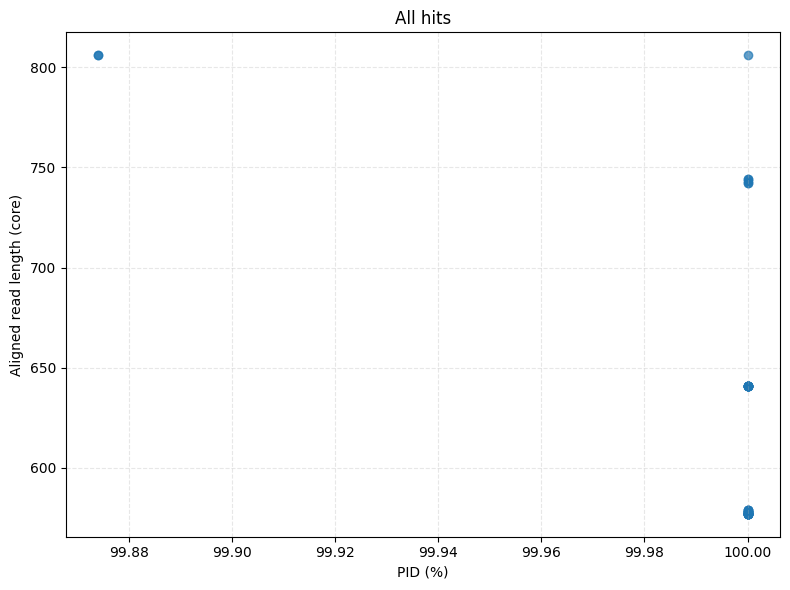

In [25]:

def plot_all_hits(df, *, min_pid=0.0, min_core=0, title="All alignments"):
    """Scatter of PID vs core length for all rows (optionally filtered)."""
    d = df.copy()
    if min_pid > 0:
        d = d[d["pid"] >= float(min_pid)]
    if min_core > 0:
        d = d[d["core_len"] >= int(min_core)]

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)
    ax.scatter(d["pid"], d["core_len"], alpha=0.7)
    ax.set_xlabel("PID (%)")
    ax.set_ylabel("Aligned read length (core)")
    ax.set_title(title)
    ax.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_all_hits(df, min_pid=0.0, min_core=0, title="All hits")


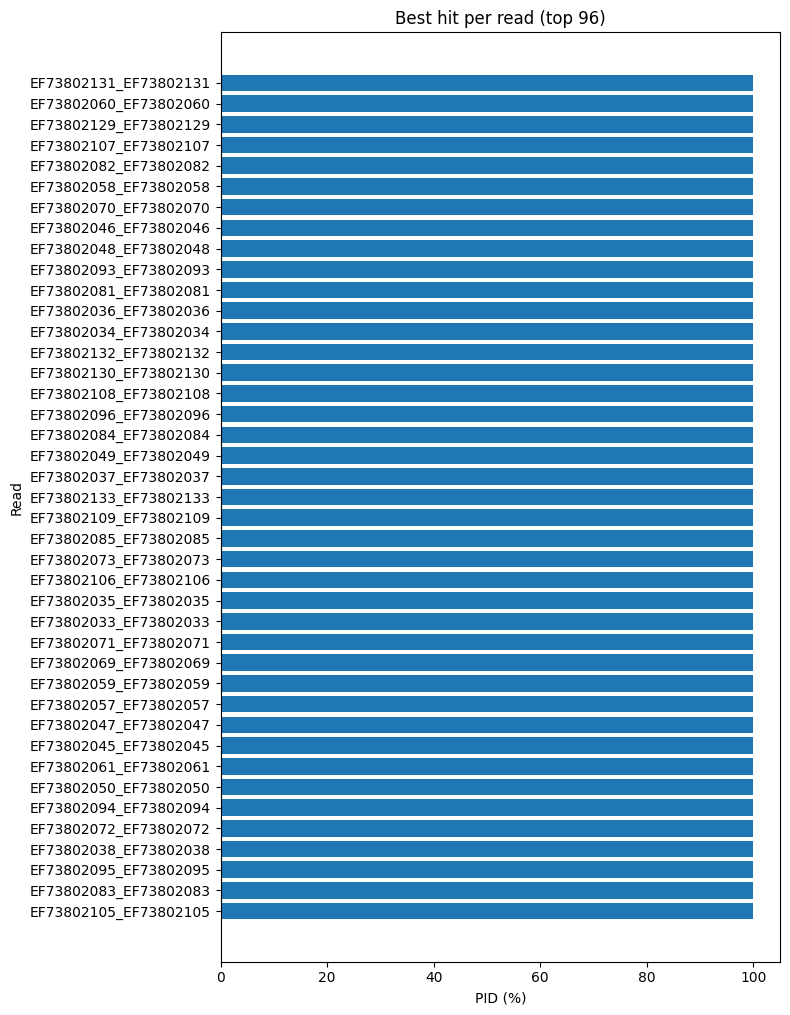

In [26]:

number=96
def plot_best_per_read(df_best, top_n=number, title="Best hit per read"):
    """Horizontal bars of PID for the top-N reads by PID."""
    d = df_best.nlargest(top_n, "pid")[["sequence_name","pid"]].copy()
    d = d.sort_values("pid")
    fig = plt.figure(figsize=(8, max(4, 0.25*len(d))))
    ax = fig.add_subplot(111)
    ax.barh(d["sequence_name"], d["pid"])
    ax.set_xlabel("PID (%)")
    ax.set_ylabel("Read")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_best_per_read(df_best, top_n=50, title=f"Best hit per read (top {number})")


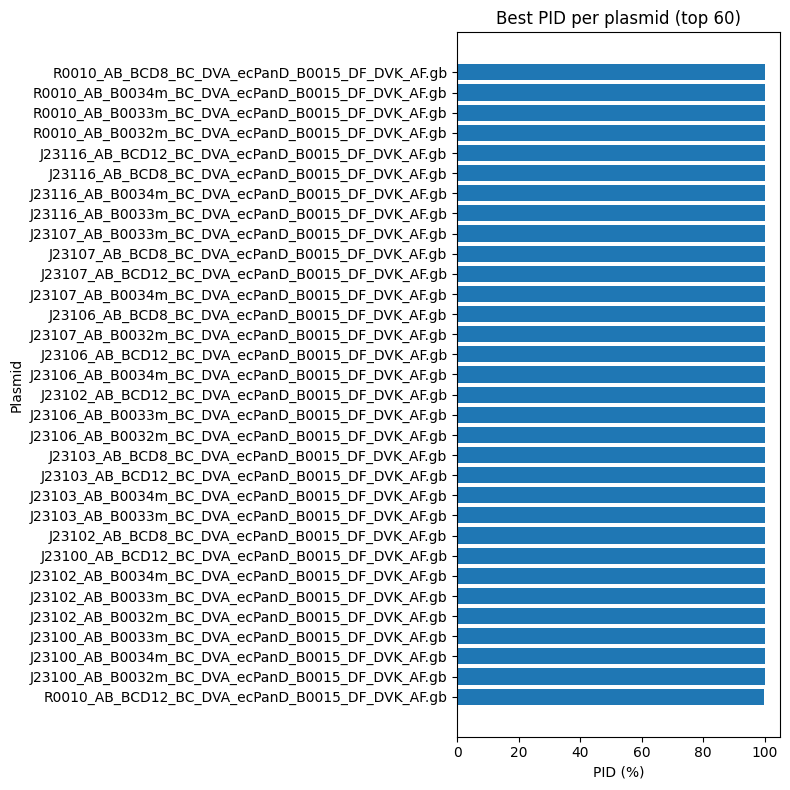

In [27]:
def plot_best_per_plasmid(df, top_n=60, title="Best PID per plasmid"):
    """For each plasmid_file, take the max PID seen; plot top-N."""
    d = (
        df.groupby("plasmid_file", as_index=False)["pid"]
          .max()
          .sort_values("pid", ascending=False)
          .head(top_n)
          .sort_values("pid")
    )
    fig = plt.figure(figsize=(8, max(4, 0.25*len(d))))
    ax = fig.add_subplot(111)
    ax.barh(d["plasmid_file"], d["pid"])
    ax.set_xlabel("PID (%)")
    ax.set_ylabel("Plasmid")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_best_per_plasmid(df, top_n=60, title="Best PID per plasmid (top 60)")


In [28]:
# ── Export results ─────────────────────────────────────────────────────────────

out_xlsx = Path("alignment_results.xlsx")
out_csv  = Path("alignment_results.csv")
inv_xlsx = Path("feature_inventory.xlsx")

# results → Excel
xlsx_path = export_results(rows, str(out_xlsx), fmt="xlsx")
print(f"Wrote Excel summary: {xlsx_path}")

# results → CSV (optional)
csv_path = export_results(rows, str(out_csv), fmt="csv")
print(f"Wrote CSV summary:   {csv_path}")

# unique tokens per slot across prepared plasmids (optional)
inv_path = export_feature_inventory(plasmids, str(inv_xlsx), fmt="xlsx")
print(f"Wrote feature inventory: {inv_path}")


Wrote Excel summary: c:\Repo\assembly_designer_test\examples\03 Sequencing\01 From single fasta\alignment_results.xlsx
Wrote CSV summary:   c:\Repo\assembly_designer_test\examples\03 Sequencing\01 From single fasta\alignment_results.csv
Wrote feature inventory: c:\Repo\assembly_designer_test\examples\03 Sequencing\01 From single fasta\feature_inventory.xlsx


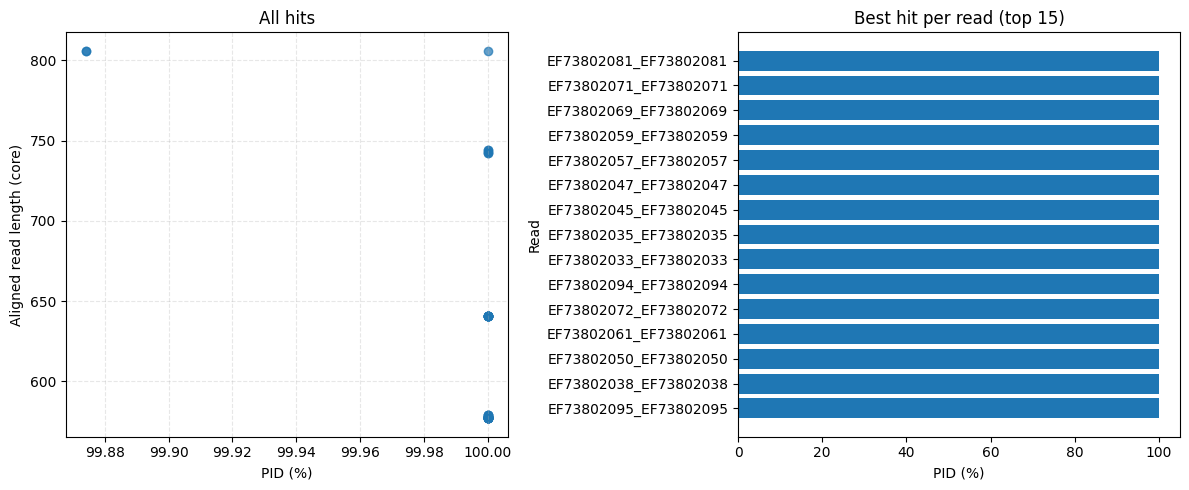

In [29]:
# ── Quick overview plot ────────────────────────────────────────────────────────
def quick_overview(df, df_best, *, fname=None):
    fig = plt.figure(figsize=(12,5))
    # left: all hits
    ax1 = fig.add_subplot(1,2,1)
    ax1.scatter(df["pid"], df["core_len"], alpha=0.7)
    ax1.set_xlabel("PID (%)"); ax1.set_ylabel("Aligned read length (core)")
    ax1.set_title("All hits"); ax1.grid(True, linestyle="--", alpha=0.3)
    # right: best per read
    d = df_best.nlargest(15, "pid")[["sequence_name","pid"]].sort_values("pid")
    ax2 = fig.add_subplot(1,2,2)
    ax2.barh(d["sequence_name"], d["pid"])
    ax2.set_xlabel("PID (%)"); ax2.set_ylabel("Read")
    ax2.set_title("Best hit per read (top 15)")
    plt.tight_layout()
    if fname:
        fig.savefig(fname, dpi=200, bbox_inches="tight")
    plt.show()

quick_overview(df, df_best, fname="overview.png")
